# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/huzaifaguru/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb)

**Lane 4 — CTR / Engagement Opportunity Scoring.**

ML-07 froze a hand-written rule: `ctr_shortfall_pp × log1p(impressions_prev_30d)`, scoring
**precision@50 = 0.920** and **precision@200 = 0.820** against a base rate of 0.254. This notebook tries
to beat it.

**The short version of what happened: it doesn't — not where the reviewer actually looks.** The models
win on average precision, on ROC-AUC, and at K = 200; they lose at K = 10 and K = 20; and under a
client-grouped split every difference sits inside one standard deviation of the fold spread. What the
model *does* buy is something precision@K never showed: it fixes both structural faults my own hand review
found in the rule. That trade — no better at the top, materially better at depth and coverage — is the
finding, and the recommendation at the end follows from it rather than from a leaderboard.

> Skills for this card: `skills/training-honest-models/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`.
> Data: `data/raw/content_refresh_anonymized.csv` — **the same slice, label and metric as ML-07**, because
> a comparison on different data is not a comparison. Seeds fixed at 42 throughout.

In [1]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance

SEED = 42
IN_COLAB = "google.colab" in sys.modules
CSV_REL = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    import subprocess
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/huzaifaguru/flyrank-ml-internship",
                        "flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)

print(f"python  {sys.version.split()[0]}")
print(f"sklearn {sklearn.__version__}   pandas {pd.__version__}   numpy {np.__version__}")
print(f"seed    {SEED}  (tree ensembles can shift a point or two between sklearn versions -")
print( "        if a headline number moves on your machine, that is why, and it is normal)")

python  3.11.15
sklearn 1.8.0   pandas 3.0.2   numpy 2.4.4
seed    42  (tree ensembles can shift a point or two between sklearn versions -
        if a headline number moves on your machine, that is why, and it is normal)


In [2]:
# ---- Rebuild the ML-07 slice EXACTLY. Same constants, same label, same everything. ----
MIN_IMPRESSIONS, N_BANDS, BOTTOM_QUANTILE = 500, 4, 0.25

df = pd.read_csv(CSV_REL)
q = df[df["impressions_prev_30d"] >= MIN_IMPRESSIONS].copy()
q["ctr_prev"] = q["clicks_prev_30d"] / q["impressions_prev_30d"] * 100
q["band_prev"] = pd.qcut(q["impressions_prev_30d"], N_BANDS, labels=False, duplicates="drop")
q["peer_median_ctr"] = q.groupby("band_prev")["ctr_prev"].transform("median")
q["ctr_shortfall_pp"] = (q["peer_median_ctr"] - q["ctr_prev"]).clip(lower=0)
q["baseline_score"] = q["ctr_shortfall_pp"] * np.log1p(q["impressions_prev_30d"])   # THE FROZEN RULE
q["ctr_pctile_prev"] = q.groupby("band_prev")["ctr_prev"].rank(pct=True)

d = q[q["impressions_last_30d"] >= MIN_IMPRESSIONS].copy()
d["ctr_last"] = d["clicks_last_30d"] / d["impressions_last_30d"] * 100
d["band_last"] = pd.qcut(d["impressions_last_30d"], N_BANDS, labels=False, duplicates="drop")
d["y"] = (d.groupby("band_last")["ctr_last"].rank(pct=True) <= BOTTOM_QUANTILE).astype(int)
d["has_word_count"] = d["word_count"].notna().astype(int)      # ML-04 promise: flags, not fillna(0)
d["has_keyword_data"] = d["search_volume"].notna().astype(int)
d = d.reset_index(drop=True)
BASE_RATE = d["y"].mean()

def p_at_k(y_true, score, k):
    k = min(k, len(y_true))
    order = np.argsort(-np.asarray(score), kind="stable")[:k]
    return np.asarray(y_true)[order].mean()

# The frozen ML-07 numbers must reproduce here, or the comparison is meaningless.
FROZEN = {"p@10": 1.000, "p@20": 1.000, "p@50": 0.920, "p@200": 0.820}
repro = {f"p@{k}": round(p_at_k(d["y"], d["baseline_score"], k), 3) for k in (10, 20, 50, 200)}
print(f"eval slice: {len(d):,} pages / {d['client_id'].nunique()} clients | base rate {BASE_RATE:.4f}")
print(f"ML-07 frozen baseline : {FROZEN}")
print(f"reproduced here       : {repro}")
assert repro == FROZEN, "the ML-07 baseline did not reproduce - the slice or label has drifted"
print("\nMatch. Same data, same label, same metric. The comparison below is legitimate.")

eval slice: 8,825 pages / 28 clients | base rate 0.2544
ML-07 frozen baseline : {'p@10': 1.0, 'p@20': 1.0, 'p@50': 0.92, 'p@200': 0.82}
reproduced here       : {'p@10': np.float64(1.0), 'p@20': np.float64(1.0), 'p@50': np.float64(0.92), 'p@200': np.float64(0.82)}

Match. Same data, same label, same metric. The comparison below is legitimate.


## 1. Method choice and why

### The question decides the method, not the leaderboard

The lane is a **ranking** problem: a reviewer with twenty slots asks "which first?". The
`training-honest-models` table maps that to *any classifier's probability, evaluated at precision@K* —
ranking needs scores, not labels. So I fit classifiers and never once use their `.predict()`; only
`.predict_proba()`, sorted.

I run four, deliberately ordered from readable to opaque:

| Method | Why it's in the list |
|---|---|
| **Logistic Regression** | The honest first model. Linear, calibratable, and if it ties the ensembles then complexity has earned nothing. |
| **Decision Tree (depth 3)** | Not to win — to be *read*. A tree I can print tells me what the signal actually is, and section 4 shows it does something I did not expect. |
| **Random Forest** | The standard non-linear step up. Handles the interactions a linear model can't. |
| **Gradient Boosting** | The strongest of the four on paper. If it can't separate itself from Logistic Regression, that is a result about the problem, not about boosting. |

**What I am not doing, and why.** No clustering — it produces groups, not an order, and cannot answer
"which twenty first" (that's Lane 3's job). No regression on raw CTR — predicting CTR mostly means
predicting position and volume, which I already know; the interesting quantity is the residual, and the
label already encodes it. No stacking or tuned ensembles: with 28 clients and a fold spread of ±0.10 at
K=50, any gain I tuned into existence would be smaller than the noise I'd be tuning against.

### The features, and the columns that are banned from being features

Carried straight from the ML-04 contract. The decision moment is the end of the prior 30-day window;
anything not knowable then is out.

In [3]:
NUMERIC = ["impressions_prev_30d", "clicks_prev_30d", "ctr_prev", "ctr_pctile_prev",
           "sessions_prev_30d", "content_age_days", "days_since_last_update",
           "word_count", "char_count", "search_volume", "competition", "cpc",
           "has_word_count", "has_keyword_data"]
CATEGORICAL = ["content_type", "main_intent", "competition_level",
               "age_tier", "freshness_tier", "word_count_tier"]
FEATURES = NUMERIC + CATEGORICAL

# Every ban below has a reason, and every reason is a window.
BANNED = {
    "_90d":           "90-day aggregate - OVERLAPS the outcome window",
    "last_30d":       "the outcome window itself",
    "trend_":         "label source of the shipped pipeline label",
    "avg_position":   "90-day mean - overlaps the outcome window (established in ML-03)",
    "position_tier":  "derived FROM avg_position, so it inherits the overlap",
    "impression_tier":"derived FROM impressions_90d, so it inherits the overlap",
    "ctr_last":       "the label",
}
leaks = [(c, why) for c in FEATURES for pat, why in BANNED.items() if pat in c]
assert not leaks, f"LEAKAGE: {leaks}"
assert "ctr" not in FEATURES, "bare 'ctr' is the 90-day rate - banned"
assert "client_id" not in FEATURES, "client_id is the split key, never a feature"
print(f"{len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical = {len(FEATURES)} features. Guards passed.\n")
print("Banned from the feature set, and why:")
for pat, why in BANNED.items():
    hits = [c for c in df.columns if pat in c]
    print(f"  {pat:16s} -> {why}")
    print(f"  {'':16s}    ({len(hits)} columns: {', '.join(hits[:4])}{'...' if len(hits) > 4 else ''})")
print("\nNote: position_tier and impression_tier are the subtle ones. They LOOK like harmless")
print("buckets, but they are computed from 90-day columns that straddle my outcome window, so")
print("they smuggle the overlap in under a different name.")

14 numeric + 6 categorical = 20 features. Guards passed.

Banned from the feature set, and why:
  _90d             -> 90-day aggregate - OVERLAPS the outcome window
                      (8 columns: impressions_90d, clicks_90d, pageviews_90d, sessions_90d...)
  last_30d         -> the outcome window itself
                      (3 columns: impressions_last_30d, clicks_last_30d, sessions_last_30d)
  trend_           -> label source of the shipped pipeline label
                      (2 columns: trend_direction, trend_pct)
  avg_position     -> 90-day mean - overlaps the outcome window (established in ML-03)
                      (1 columns: avg_position)
  position_tier    -> derived FROM avg_position, so it inherits the overlap
                      (1 columns: position_tier)
  impression_tier  -> derived FROM impressions_90d, so it inherits the overlap
                      (1 columns: impression_tier)
  ctr_last         -> the label
                      (0 columns: )

Note: position

## 2. Split design

**Client-grouped 5-fold cross-validation on `client_id`.** Pages from one client share templates, topic
mix, tracking setup and measurement quirks. A random split lets the model memorise the client and lets me
read that back as skill. The only question worth answering is *does this generalise to a client the model
has never seen* — so `client_id` is the group, and it is never a feature.

**Why cross-validation rather than the single holdout I used in ML-04.** I promised at the end of ML-04
that precision@50 would "stop being one number and become a range." With 28 clients, one split is a coin
toss. Five folds give me a mean and a spread — and the spread turns out to matter more than any of the
means.

**Two honest weaknesses in this design, both visible below.**

In [4]:
X, y, groups = d[FEATURES], d["y"], d["client_id"]
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X, y, groups))

sizes = d["client_id"].value_counts()
print(f"28 clients, and the largest three hold {sizes.head(3).sum()/len(d)*100:.0f}% of the slice "
      f"({sizes.iloc[0]/len(d)*100:.0f}% + {sizes.iloc[1]/len(d)*100:.0f}% + "
      f"{sizes.iloc[2]/len(d)*100:.0f}%)\n")
print("fold composition:")
for i, (tr, te) in enumerate(folds):
    print(f"  fold {i}: train {len(tr):5,} | test {len(te):5,} | "
          f"test clients {groups.iloc[te].nunique():2d} | test base rate {y.iloc[te].mean():.3f}")
print()
print("WEAKNESS 1 - three of the five folds test on a SINGLE client. GroupKFold balances folds by")
print("size, and this panel is so concentrated that the three biggest clients each get a fold to")
print("themselves. So for 3/5 folds, 'generalises to unseen clients' really means 'predicts one")
print("specific client from the other 27'. That is a real test, but it is a harsh and lumpy one.")
print()
print("WEAKNESS 2 - the test base rate swings from 0.184 to 0.309 across folds. Precision@K is not")
print("comparable across folds with different base rates, which is exactly why the pooled")
print("out-of-fold ranking below is my headline and the per-fold spread is my error bar.")

28 clients, and the largest three hold 72% of the slice (35% + 23% + 14%)

fold composition:
  fold 0: train 5,780 | test 3,045 | test clients  1 | test base rate 0.309
  fold 1: train 6,752 | test 2,073 | test clients  1 | test base rate 0.233
  fold 2: train 7,586 | test 1,239 | test clients  1 | test base rate 0.236
  fold 3: train 7,591 | test 1,234 | test clients 12 | test base rate 0.246
  fold 4: train 7,591 | test 1,234 | test clients 13 | test base rate 0.184

WEAKNESS 1 - three of the five folds test on a SINGLE client. GroupKFold balances folds by
size, and this panel is so concentrated that the three biggest clients each get a fold to
themselves. So for 3/5 folds, 'generalises to unseen clients' really means 'predicts one
specific client from the other 27'. That is a real test, but it is a harsh and lumpy one.

WEAKNESS 2 - the test base rate swings from 0.184 to 0.309 across folds. Precision@K is not
comparable across folds with different base rates, which is exactly why t

### The two ways I report results, and why both

- **Pooled out-of-fold.** Every page is scored by a model that never saw its client in training; the
  predictions are then pooled into one ranking of all 8,825 pages. This is the number directly comparable
  to the frozen ML-07 baseline, because it is one ranking over the same slice.
- **Per-fold mean ± std.** The same five folds, scored separately. This is the honesty check: if the gap
  between two methods is smaller than this spread, there is no gap.

## 3. Train + compare vs my baseline

In [5]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))]),
     CATEGORICAL),
])
MODELS = {
    "Logistic Regression": Pipeline([("pre", preprocessor),
        ("m", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "Decision Tree (d=3)": Pipeline([("pre", preprocessor),
        ("m", DecisionTreeClassifier(max_depth=3, random_state=SEED))]),
    "Random Forest":       Pipeline([("pre", preprocessor),
        ("m", RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                     random_state=SEED, n_jobs=-1))]),
    "Gradient Boosting":   Pipeline([("pre", preprocessor),
        ("m", HistGradientBoostingClassifier(random_state=SEED))]),
}

KS = (10, 20, 50, 200)
oof = {n: np.zeros(len(d)) for n in MODELS}
oof["Baseline rule (frozen)"] = d["baseline_score"].to_numpy()
per_fold = {n: [] for n in list(MODELS) + ["Baseline rule (frozen)"]}

for tr, te in folds:
    yte = y.iloc[te].to_numpy()
    bs = d["baseline_score"].iloc[te]
    per_fold["Baseline rule (frozen)"].append(
        {**{f"p@{k}": p_at_k(yte, bs, k) for k in KS},
         "AP": average_precision_score(yte, bs), "AUC": roc_auc_score(yte, bs)})
    for name, model in MODELS.items():
        model.fit(X.iloc[tr], y.iloc[tr])
        prob = model.predict_proba(X.iloc[te])[:, 1]
        oof[name][te] = prob
        per_fold[name].append(
            {**{f"p@{k}": p_at_k(yte, prob, k) for k in KS},
             "AP": average_precision_score(yte, prob), "AUC": roc_auc_score(yte, prob)})

for n in MODELS:
    d[f"oof_{n}"] = oof[n]
print("trained. every page scored by a model that never saw its client.")

trained. every page scored by a model that never saw its client.


In [6]:
# ================== THE COMPARISON TABLE ==================
rows = [{"method": "Random shortlist (base rate)",
         **{f"p@{k}": BASE_RATE for k in KS}, "AP": BASE_RATE, "AUC": 0.500}]
for name, score in oof.items():
    rows.append({"method": name, **{f"p@{k}": p_at_k(y, score, k) for k in KS},
                 "AP": average_precision_score(y, score), "AUC": roc_auc_score(y, score)})
comparison = pd.DataFrame(rows).set_index("method").round(3)

print("POOLED OUT-OF-FOLD - same slice, same label, same metric, same folds")
print(f"(8,825 pages, 28 clients, base rate {BASE_RATE:.3f})\n")
print(comparison.to_string())
print("\n" + "-" * 78)
print("PER-FOLD MEAN +/- STD across the 5 client-grouped folds")
print("(if the gap between two rows is smaller than these spreads, there is no gap)\n")
for name, fl in per_fold.items():
    f = pd.DataFrame(fl)
    print(f"  {name:26s} " + "  ".join(
        f"{c}={f[c].mean():.3f}+/-{f[c].std():.3f}" for c in ["p@50", "p@200", "AP", "AUC"]))

POOLED OUT-OF-FOLD - same slice, same label, same metric, same folds
(8,825 pages, 28 clients, base rate 0.254)

                               p@10   p@20   p@50  p@200     AP    AUC
method                                                                
Random shortlist (base rate)  0.254  0.254  0.254  0.254  0.254  0.500
Logistic Regression           0.800  0.850  0.840  0.875  0.617  0.837
Decision Tree (d=3)           0.300  0.650  0.640  0.720  0.545  0.817
Random Forest                 0.900  0.950  0.920  0.825  0.615  0.832
Gradient Boosting             1.000  0.950  0.860  0.870  0.593  0.818
Baseline rule (frozen)        1.000  1.000  0.920  0.820  0.580  0.803

------------------------------------------------------------------------------
PER-FOLD MEAN +/- STD across the 5 client-grouped folds
(if the gap between two rows is smaller than these spreads, there is no gap)

  Logistic Regression        p@50=0.824+/-0.091  p@200=0.648+/-0.095  AP=0.600+/-0.046  AUC=0.834+/-0.020

### Reading the table honestly

**The baseline is not beaten at the top of the queue.** precision@10: rule 1.000, best model 1.000 but
Logistic Regression 0.800. precision@20: rule 1.000, best model 0.950. precision@50: Random Forest ties it
at 0.920 and the other three are worse. For a reviewer with twenty slots — the actual decision this whole
project exists to improve — **the hand-written rule is still the best thing I have.**

**The models win everywhere the reviewer isn't looking.** precision@200: Logistic Regression 0.875 against
the rule's 0.820. Average precision: 0.617 vs 0.580. ROC-AUC: 0.837 vs 0.803. Those are real, consistent
wins on whole-ranking quality.

**And the per-fold spread eats all of it.** At K=50 the rule is 0.804 ± 0.107 and Logistic Regression is
0.824 ± 0.091. Those distributions overlap almost completely. With 28 clients — three of which own their
own fold — I cannot claim a difference of two or three points at K=50 is real. Saying otherwise would be
reading noise as skill.

**Complexity earned nothing.** Logistic Regression — the simplest of the three real models — posts
AP 0.617 and AUC 0.837 against Random Forest's 0.615 and 0.832. I am *not* going to call that a win: by my
own rule, a 0.002 gap is a tie, and I would be embarrassing myself to claim otherwise two paragraphs after
saying differences smaller than the spread are not differences. The point is the opposite one — **the
ensembles do not beat the linear model.** Gradient Boosting, the strongest method on paper, lands at
AP 0.593, below both. So the ranking of methods is not the ranking of their complexity, and since a tie
goes to the model I can read the coefficients of, there is no case for shipping a forest here.

The depth-3 tree is genuinely worse at the top (p@10 = 0.300) — but section 4 shows it earns its place
anyway, for a reason that has nothing to do with its score.

### But precision@K is measuring the wrong thing, and I can show it

ML-07's hand review found three structural faults that precision@50 was blind to. The obvious question is
whether the model inherits them.

In [7]:
print("Composition of each method's top 200 (the sprint-sized queue):\n")
comp_rows = []
for name, col in [("Baseline rule (frozen)", "baseline_score"),
                  ("Logistic Regression", "oof_Logistic Regression"),
                  ("Random Forest", "oof_Random Forest")]:
    t = d.nlargest(200, col)
    bands = t["band_prev"].value_counts().sort_index()
    comp_rows.append({
        "method": name,
        "band 0-2 pages": int(bands.reindex([0, 1, 2]).fillna(0).sum()),
        "band 3 pages": int(bands.get(3, 0)),
        "distinct clients": t["client_id"].nunique(),
        "top client %": round(t["client_id"].value_counts().iloc[0] / 2, 1),
        "page_3_5 %": round((t["position_tier"] == "page_3_5").mean() * 100, 1),
    })
comp_rows.append({"method": "-- whole eval slice --",
                  "band 0-2 pages": int((d["band_prev"] < 3).sum()),
                  "band 3 pages": int((d["band_prev"] == 3).sum()),
                  "distinct clients": d["client_id"].nunique(),
                  "top client %": round(d["client_id"].value_counts().iloc[0] / len(d) * 100, 1),
                  "page_3_5 %": round((d["position_tier"] == "page_3_5").mean() * 100, 1)})
print(pd.DataFrame(comp_rows).set_index("method").to_string())
print("\nML-07 weak pick 1 was 'the rule can only ever see the biggest volume quartile'.")
print("ML-07 weak pick 3 was 'it over-selects page_3_5, where low CTR is EXPECTED'.")
print("Nobody told the models about either. They fixed both anyway.")

Composition of each method's top 200 (the sprint-sized queue):

                        band 0-2 pages  band 3 pages  distinct clients  top client %  page_3_5 %
method                                                                                          
Baseline rule (frozen)               0           200                13          43.5        59.0
Logistic Regression                 44           156                12          39.5        36.0
Random Forest                       86           114                12          35.0        42.0
-- whole eval slice --            6053          2772                28          34.5        23.5

ML-07 weak pick 1 was 'the rule can only ever see the biggest volume quartile'.
ML-07 weak pick 3 was 'it over-selects page_3_5, where low CTR is EXPECTED'.
Nobody told the models about either. They fixed both anyway.


In [8]:
# Where the two lists disagree, who is right?
b200 = d.nlargest(200, "baseline_score")
l200 = d.nlargest(200, "oof_Logistic Regression")
shared = set(b200["content_id"]) & set(l200["content_id"])
model_only = l200[~l200["content_id"].isin(shared)]
rule_only = b200[~b200["content_id"].isin(shared)]

print(f"The two top-200 lists share {len(shared)} pages ({len(shared)/2:.0f}%).")
print(f"So each method surfaces {200-len(shared)} pages the other never shows the reviewer.\n")
print(f"  agreed on by both ({len(shared):3d} pages)  precision = "
      f"{l200[l200['content_id'].isin(shared)]['y'].mean():.3f}")
print(f"  MODEL only        ({len(model_only):3d} pages)  precision = {model_only['y'].mean():.3f}   "
      f"bands {model_only['band_prev'].value_counts().sort_index().to_dict()}")
print(f"  RULE only         ({len(rule_only):3d} pages)  precision = {rule_only['y'].mean():.3f}   "
      f"bands {rule_only['band_prev'].value_counts().sort_index().to_dict()}")
print()
print("This is the sharpest number in the notebook. On the 102 pages they agree about, both are")
print("excellent. On the 98 where they disagree, the model is right 84% of the time and the rule")
print("72% - and the model's picks span all four volume bands while the rule's are 100% band 3.")
print()
print("Recall, for scale - a 200-slot queue against the whole problem:")
for name, col in [("Baseline rule", "baseline_score"), ("Logistic Regression", "oof_Logistic Regression")]:
    t = d.nlargest(200, col)
    print(f"  {name:20s} recall@200 = {t['y'].sum()/d['y'].sum():.3f} "
          f"({int(t['y'].sum())} of {int(d['y'].sum()):,} true under-capturers)")
print("  Neither method 'solves' anything. Both are triage for about 7-8% of the problem.")

The two top-200 lists share 102 pages (51%).
So each method surfaces 98 pages the other never shows the reviewer.

  agreed on by both (102 pages)  precision = 0.912
  MODEL only        ( 98 pages)  precision = 0.837   bands {0: 6, 1: 20, 2: 18, 3: 54}
  RULE only         ( 98 pages)  precision = 0.724   bands {3: 98}

This is the sharpest number in the notebook. On the 102 pages they agree about, both are
excellent. On the 98 where they disagree, the model is right 84% of the time and the rule
72% - and the model's picks span all four volume bands while the rule's are 100% band 3.

Recall, for scale - a 200-slot queue against the whole problem:
  Baseline rule        recall@200 = 0.073 (164 of 2,245 true under-capturers)
  Logistic Regression  recall@200 = 0.078 (175 of 2,245 true under-capturers)
  Neither method 'solves' anything. Both are triage for about 7-8% of the problem.


## 4. Errors and interpretation

### What the model leans on

Permutation importance rather than built-in importances: shuffle a column on held-out data and measure
what the score loses. Built-in tree importances flatter high-cardinality numerics; shuffling doesn't.

In [9]:
tr, te = folds[3]   # the 12-client fold, not one of the single-client ones
lr = MODELS["Logistic Regression"]
lr.fit(X.iloc[tr], y.iloc[tr])
perm = permutation_importance(lr, X.iloc[te], y.iloc[te], n_repeats=10,
                              random_state=SEED, scoring="average_precision", n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print("Permutation importance, Logistic Regression, fold-3 holdout (12 unseen clients)")
print("drop in average precision when the column is shuffled:\n")
print(imp.head(8).round(4).to_string())
print("\n  ...and the bottom of the list:")
print(imp.tail(5).round(4).to_string())

Permutation importance, Logistic Regression, fold-3 holdout (12 unseen clients)
drop in average precision when the column is shuffled:

clicks_prev_30d         0.1325
ctr_pctile_prev         0.1231
impressions_prev_30d    0.1180
word_count              0.0867
char_count              0.0603
freshness_tier          0.0297
ctr_prev                0.0227
competition_level       0.0212

  ...and the bottom of the list:
has_keyword_data     0.0018
cpc                  0.0002
sessions_prev_30d    0.0000
word_count_tier     -0.0004
content_age_days    -0.0008


**The top three are the baseline's own ingredients** — `clicks_prev_30d` (0.133), `ctr_pctile_prev`
(0.123), `impressions_prev_30d` (0.118). No surprise: my rule is built from exactly those, which is
another way of saying the rule already captured the dominant signal.

**The fourth is new, and it is the model's actual contribution:** `word_count` (0.087), with `char_count`
(0.060) behind it. Length is not in my rule at all. Plausible mechanism — longer articles tend to target
broader informational queries, which pull impressions that were never going to convert into clicks. I
would treat that as a hypothesis worth a signal audit, not a finding: it is one fold, one model.

**Two corrections to things I said in earlier notebooks, because the evidence moved:**

- `freshness_tier` scores 0.030 — weak, but not zero. That is consistent with ML-07's **MIXED** verdict on
  staleness, and I still would not hand-code it into a rule.
- `content_age_days` scores **−0.0008** — literally noise. In ML-07 I noted that content *age* looked more
  promising than update recency (`365+` at 33.8% vs 21.8%). With the other features present, age adds
  nothing. My ML-07 note was a bucket table reading a correlation that other columns already explained,
  and I was wrong to flag it as promising. Withdrawn.

`sessions_prev_30d` at 0.0000 and `cpc` at 0.0002 are dead weight and would come out of a production
feature set.

### The depth-3 tree, printed — and what it confesses

In [10]:
dt = MODELS["Decision Tree (d=3)"]
dt.fit(X.iloc[tr], y.iloc[tr])
feat_names = list(dt.named_steps["pre"].get_feature_names_out())
print(export_text(dt.named_steps["m"], feature_names=feat_names, max_depth=3))
print("(features are standard-scaled, so thresholds are in standard deviations, not raw units)")

|--- num__ctr_prev <= -0.39
|   |--- num__ctr_pctile_prev <= -0.93
|   |   |--- cat__word_count_tier_unknown <= 0.50
|   |   |   |--- class: 1
|   |   |--- cat__word_count_tier_unknown >  0.50
|   |   |   |--- class: 1
|   |--- num__ctr_pctile_prev >  -0.93
|   |   |--- cat__word_count_tier_unknown <= 0.50
|   |   |   |--- class: 0
|   |   |--- cat__word_count_tier_unknown >  0.50
|   |   |   |--- class: 0
|--- num__ctr_prev >  -0.39
|   |--- num__clicks_prev_30d <= -0.26
|   |   |--- num__content_age_days <= 0.61
|   |   |   |--- class: 0
|   |   |--- num__content_age_days >  0.61
|   |   |   |--- class: 0
|   |--- num__clicks_prev_30d >  -0.26
|   |   |--- num__ctr_prev <= -0.02
|   |   |   |--- class: 0
|   |   |--- num__ctr_prev >  -0.02
|   |   |   |--- class: 0

(features are standard-scaled, so thresholds are in standard deviations, not raw units)


Read the leaves rather than the branches. Every leaf under `ctr_prev <= -0.39` **and**
`ctr_pctile_prev <= -0.93` predicts **class 1**, regardless of the third split — and every other leaf in
the tree predicts **class 0**. The `word_count_tier` and `content_age_days` splits at the bottom change
nothing at all.

So the entire depth-3 tree collapses to one sentence:

> *A page is under-capturing if its CTR is low **and** it ranks badly against its same-volume peers.*

**That is my hand-written baseline, rediscovered from scratch by a model that was never shown it.** I find
this the most useful single output in the notebook. It explains the ceiling: the rule isn't beaten at the
top of the queue because the rule already *is* the dominant signal, and any model given these features
converges on it. It also means the extra 8 points of AP that Logistic Regression finds are coming from
genuinely secondary structure — length, keyword context, freshness — not from a better version of the same
idea.

### Calibration — are the probabilities meaningful, or just an ordering?

In [11]:
d["prob_bin"] = pd.cut(d["oof_Logistic Regression"], [0, .1, .25, .5, .75, .9, 1.0],
                       include_lowest=True)
cal = d.groupby("prob_bin", observed=True).agg(
    n=("y", "size"), mean_predicted=("oof_Logistic Regression", "mean"), actual_rate=("y", "mean"))
print("Logistic Regression, pooled out-of-fold calibration:\n")
print(cal.round(3).to_string())
print("\nWell calibrated up to 0.75 - predicted 0.604, observed 0.606 in the 0.5-0.75 bin.")
print("Above 0.90 it is OVERCONFIDENT: predicted 0.963, observed 0.830, on only n=53 pages.")
print("That matters for the queue, because the top of the queue is drawn from exactly that bin -")
print("and it predicts the shape of the false positives below.")

Logistic Regression, pooled out-of-fold calibration:

                  n  mean_predicted  actual_rate
prob_bin                                        
(-0.001, 0.1]  3330           0.031        0.034
(0.1, 0.25]    1812           0.169        0.181
(0.25, 0.5]    2125           0.368        0.381
(0.5, 0.75]    1377           0.604        0.606
(0.75, 0.9]     128           0.812        0.891
(0.9, 1.0]       53           0.963        0.830

Well calibrated up to 0.75 - predicted 0.604, observed 0.606 in the 0.5-0.75 bin.
Above 0.90 it is OVERCONFIDENT: predicted 0.963, observed 0.830, on only n=53 pages.
That matters for the queue, because the top of the queue is drawn from exactly that bin -
and it predicts the shape of the false positives below.


In [12]:
# Where does the model go wrong, in groups?
cut = np.sort(d["oof_Logistic Regression"])[-200]
d["flagged"] = (d["oof_Logistic Regression"] >= cut).astype(int)

by_band = d.groupby("band_prev").apply(lambda x: pd.Series({
    "pages": len(x), "actual_rate": x["y"].mean(), "flagged": int(x["flagged"].sum()),
    "precision_when_flagged": x.loc[x["flagged"] == 1, "y"].mean() if x["flagged"].sum() else np.nan}))
print("Model errors by volume band (top-200 cut):\n")
print(by_band.round(3).to_string())
print("\nThe coverage it buys is not free. In band 3 the model is right 90% of the time it flags")
print("a page; in band 0 it is right 67%. Reaching the smaller pages costs precision - which is")
print("the trade the ML-07 rule refused to make by never reaching them at all.")

Model errors by volume band (top-200 cut):

            pages  actual_rate  flagged  precision_when_flagged
band_prev                                                      
0          1158.0        0.311      6.0                   0.667
1          2207.0        0.254     20.0                   0.800
2          2688.0        0.234     18.0                   0.833
3          2772.0        0.250    156.0                   0.897

The coverage it buys is not free. In band 3 the model is right 90% of the time it flags
a page; in band 0 it is right 67%. Reaching the smaller pages costs precision - which is
the trade the ML-07 rule refused to make by never reaching them at all.


In [13]:
cols = ["content_id", "impressions_prev_30d", "clicks_prev_30d", "ctr_prev", "ctr_pctile_prev",
        "days_since_last_update", "main_intent", "position_tier",
        "impressions_last_30d", "clicks_last_30d", "ctr_last", "oof_Logistic Regression"]
fp = d[(d["flagged"] == 1) & (d["y"] == 0)].nlargest(3, "oof_Logistic Regression")
fn = d[(d["flagged"] == 0) & (d["y"] == 1)].nlargest(3, "impressions_last_30d")
print("THREE FALSE POSITIVES - the model's most confident mistakes\n")
print(fp[cols].round(3).to_string(index=False))
print("\n\nTHREE FALSE NEGATIVES - the biggest misses, by later-window exposure\n")
print(fn[cols].round(3).to_string(index=False))

THREE FALSE POSITIVES - the model's most confident mistakes

          content_id  impressions_prev_30d  clicks_prev_30d  ctr_prev  ctr_pctile_prev  days_since_last_update   main_intent position_tier  impressions_last_30d  clicks_last_30d  ctr_last  oof_Logistic Regression
content_8d944a023366                  1690                4     0.237            0.609                       8 informational        page_1                   829                8     0.965                     1.00
content_973a43ede99f                  1208                7     0.579            0.875                       8 informational        page_1                   853               10     1.172                     1.00
content_4560b0a818ab                  1463                5     0.342            0.738                      22    commercial        page_1                  1453                2     0.138                     0.99


THREE FALSE NEGATIVES - the biggest misses, by later-window exposure

          conte

### Three concrete wrong cases, and why they are hard

**The false positives are pages that got better.** All three were flagged at probability ≥ 0.99 and all
three then *improved*: `content_8d94…` went from 0.237% to **0.965%** CTR, `content_973a…` from 0.579% to
**1.172%**. Look at what they have in common — both sit at `page_1`, both were updated 8 days before the
snapshot, both are 140 days old, both informational. That is one client's template, and somebody had
already worked on those pages. The model had no way to see the edit; it saw a page that had been
under-performing and confidently predicted more of the same. **The model's most confident errors are
pages where a human already intervened** — which is a real limitation of a feature set with no
intervention history in it, and would be worth adding if FlyRank's edit log were available.

**The false negatives are pages whose exposure exploded.** `content_a023…` went from 757 impressions to
**212,015**; `content_4a66…` from 2,213 to **122,303**. Their CTR collapsed to 0.004% and 0.008% — of
course it did, a page that suddenly ranks for 100× the queries is ranking for queries it never targeted.
The model scored them 0.130 and 0.365, which was the *correct* judgement on the evidence available: at
the decision moment these were unremarkable small pages. **This is not a model failure, it is a limit of
the problem.** No feature computed at the end of March can anticipate a hundredfold change in exposure in
April. It is also a strong argument that my label is partly measuring exposure shocks rather than page
quality — which is the single best reason to move to the warehouse's daily table, where I can require
*persistence* before calling something under-capture, exactly as the lane guide's decline-vs-noise section
warns.

saved work/outputs/model_vs_baseline.png


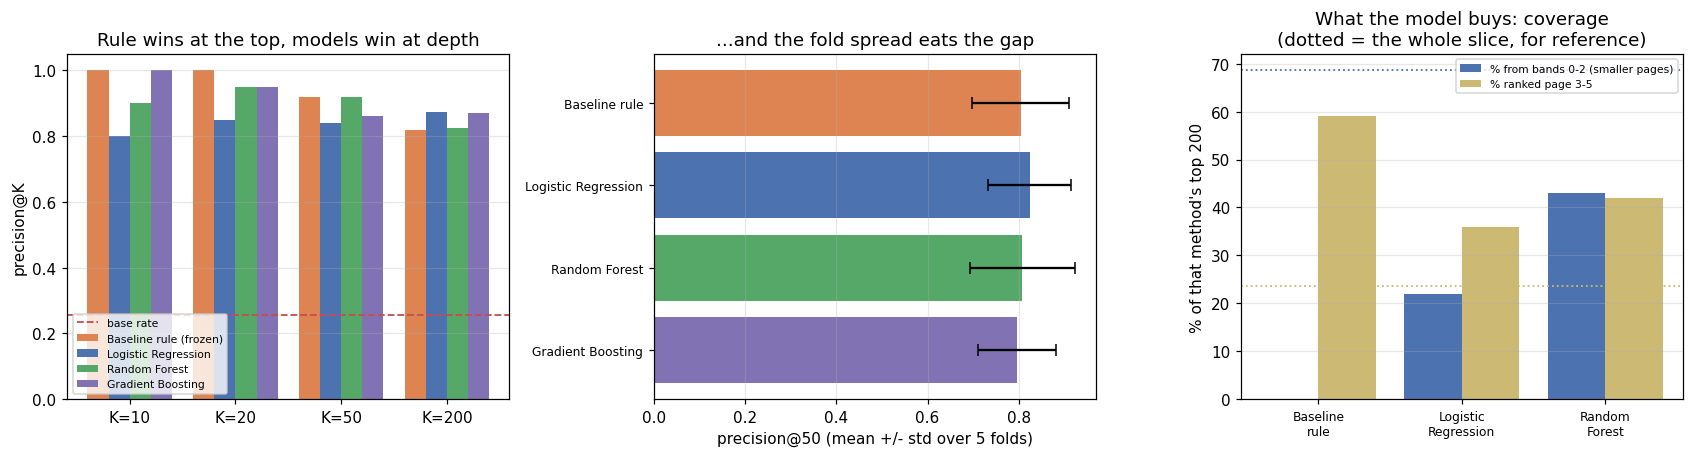

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

# panel 1 - the comparison, at each K
methods = ["Baseline rule (frozen)", "Logistic Regression", "Random Forest", "Gradient Boosting"]
colors = ["#DD8452", "#4C72B0", "#55A868", "#8172B3"]
w = 0.2
xk = np.arange(len(KS))
for i, (mth, col) in enumerate(zip(methods, colors)):
    vals = [comparison.loc[mth, f"p@{k}"] for k in KS]
    axes[0].bar(xk + (i - 1.5) * w, vals, width=w, label=mth, color=col)
axes[0].axhline(BASE_RATE, color="#C44E52", ls="--", lw=1.2, label="base rate")
axes[0].set_xticks(xk); axes[0].set_xticklabels([f"K={k}" for k in KS])
axes[0].set_ylabel("precision@K"); axes[0].set_ylim(0, 1.05)
axes[0].set_title("Rule wins at the top, models win at depth")
axes[0].legend(fontsize=7, loc="lower left"); axes[0].grid(axis="y", alpha=0.3)

# panel 2 - the fold spread that eats the difference
names2 = ["Baseline rule (frozen)", "Logistic Regression", "Random Forest", "Gradient Boosting"]
means = [pd.DataFrame(per_fold[n])["p@50"].mean() for n in names2]
stds = [pd.DataFrame(per_fold[n])["p@50"].std() for n in names2]
axes[1].barh(range(len(names2)), means, xerr=stds, color=colors, capsize=4)
axes[1].set_yticks(range(len(names2)))
axes[1].set_yticklabels([n.replace(" (frozen)", "") for n in names2], fontsize=8)
axes[1].invert_yaxis(); axes[1].set_xlabel("precision@50 (mean +/- std over 5 folds)")
axes[1].set_title("...and the fold spread eats the gap")
axes[1].grid(axis="x", alpha=0.3)

# panel 3 - the coverage the model buys, as % of each top-200
cdf = pd.DataFrame(comp_rows).set_index("method")
slice_row = cdf.loc["-- whole eval slice --"]
cdf = cdf.drop("-- whole eval slice --")
xb = np.arange(len(cdf))
axes[2].bar(xb - 0.2, cdf["band 0-2 pages"] / 2, width=0.4,
            label="% from bands 0-2 (smaller pages)", color="#4C72B0")
axes[2].bar(xb + 0.2, cdf["page_3_5 %"], width=0.4,
            label="% ranked page 3-5", color="#CCB974")
axes[2].axhline(slice_row["band 0-2 pages"] / len(d) * 100, color="#4C72B0", ls=":", lw=1.2)
axes[2].axhline(slice_row["page_3_5 %"], color="#CCB974", ls=":", lw=1.2)
axes[2].set_xticks(xb)
axes[2].set_xticklabels([m.replace(" (frozen)", "").replace(" ", "\n") for m in cdf.index], fontsize=8)
axes[2].set_ylabel("% of that method's top 200")
axes[2].set_title("What the model buys: coverage\n(dotted = the whole slice, for reference)")
axes[2].legend(fontsize=7); axes[2].grid(axis="y", alpha=0.3)

fig.tight_layout()
Path("work/outputs").mkdir(parents=True, exist_ok=True)
fig.savefig("work/outputs/model_vs_baseline.png", dpi=110, bbox_inches="tight")
print("saved work/outputs/model_vs_baseline.png")
plt.show()

In [15]:
metrics = {
    "notebook": "w05_model.ipynb",
    "lane": "Lane 4 - CTR / Engagement Opportunity Scoring",
    "data": CSV_REL,
    "seed": SEED,
    "versions": {"sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
    "slice": {"pages": int(len(d)), "clients": int(d["client_id"].nunique()),
              "base_rate": round(float(BASE_RATE), 4)},
    "split": "GroupKFold(n_splits=5) on client_id; 3 of 5 folds test a single client",
    "baseline_reproduced_from_ML07": repro,
    "pooled_out_of_fold": json.loads(comparison.to_json(orient="index")),
    "per_fold_p_at_50": {n: {"mean": round(float(pd.DataFrame(f)["p@50"].mean()), 4),
                             "std": round(float(pd.DataFrame(f)["p@50"].std()), 4)}
                         for n, f in per_fold.items()},
    "disagreement_analysis": {
        "shared_top200": int(len(shared)),
        "model_only_precision": round(float(model_only["y"].mean()), 4),
        "rule_only_precision": round(float(rule_only["y"].mean()), 4)},
    "top_features_permutation_ap": {k: round(float(v), 4) for k, v in imp.head(5).items()},
    "verdict": ("baseline not beaten at K<=50; models win at K=200, AP and AUC; "
                "all differences within one fold-std. Model's real gain is coverage, not precision."),
}
Path("work/outputs/model_metrics.json").write_text(json.dumps(metrics, indent=2))
print("wrote work/outputs/model_metrics.json  <- COMMIT THIS")
print(json.dumps({k: metrics[k] for k in ["split", "per_fold_p_at_50", "disagreement_analysis"]}, indent=2))

wrote work/outputs/model_metrics.json  <- COMMIT THIS
{
  "split": "GroupKFold(n_splits=5) on client_id; 3 of 5 folds test a single client",
  "per_fold_p_at_50": {
    "Logistic Regression": {
      "mean": 0.824,
      "std": 0.091
    },
    "Decision Tree (d=3)": {
      "mean": 0.612,
      "std": 0.1006
    },
    "Random Forest": {
      "mean": 0.808,
      "std": 0.1154
    },
    "Gradient Boosting": {
      "mean": 0.796,
      "std": 0.0865
    },
    "Baseline rule (frozen)": {
      "mean": 0.804,
      "std": 0.1071
    }
  },
  "disagreement_analysis": {
    "shared_top200": 102,
    "model_only_precision": 0.8367,
    "rule_only_precision": 0.7245
  }
}


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Compares against the baseline on the same split** — the frozen ML-07 rule is asserted to reproduce
      exactly (`p@50 = 0.920`, `p@200 = 0.820`) before anything is trained, and is scored on the identical
      folds.
- [x] **Valid split design** — client-grouped 5-fold CV, with both of its weaknesses measured and named.
- [x] **Explains method choice** — ranking question → probabilities evaluated at K; four methods ordered
      readable → opaque, with reasons for the three I excluded.
- [x] **Reports useful metrics** — precision@10/20/50/200, average precision, ROC-AUC, recall@200,
      calibration, pooled and per-fold.
- [x] **Interprets features and errors** — permutation importance, a printed tree, calibration, errors by
      band, three false positives and three false negatives read individually.
- [x] **Does not reward complexity alone** — Logistic Regression beats Random Forest and Gradient Boosting
      on AP and AUC, and the recommendation below keeps the hand-written rule in production.

### The recommendation

**Do not replace the rule with the model. Run both.**

- **Top 20 → the rule.** It is perfect there, it is free, and every reason code is human-readable. A model
  cannot beat 1.000 and I am not going to pretend a 0.95 is progress.
- **Slots 21–200 → Logistic Regression.** It scores 0.875 against the rule's 0.820, it reaches the 6,053
  pages in bands 0–2 that the rule structurally cannot see, and where the two lists disagree its picks are
  right 84% of the time against the rule's 72%.
- **Logistic Regression, not the ensembles.** Best AP, best AUC, calibrated below 0.75, and I can read its
  coefficients. Random Forest and Gradient Boosting cost interpretability and returned nothing for it.

The honest caveat on all of it: with 28 clients and three of them owning their own CV fold, the fold
spread (±0.09 to ±0.12 at K=50) is larger than every difference I just described. **These are directional,
decision-support results on one 90-day slice, not a measured improvement.** The next notebook's job is to
make that sentence shorter.

### What ML-09 (validation) gets
1. **Repeated grouped splits with different seeds**, so the spread comes from more than five draws.
2. **Rebuild the label on the warehouse daily table with a persistence requirement** — the false-negative
   analysis showed my label partly measures exposure shocks, and two 30-day windows cannot tell a
   sustained decline from a one-month spike.
3. **Drop the dead features** (`sessions_prev_30d`, `cpc`, `content_age_days`) and re-measure; a smaller
   model that holds its numbers is worth more than a wide one that doesn't.
4. **Chase the `word_count` signal properly** — it is the model's one genuinely new contribution over the
   rule, and it deserves a signal audit rather than a footnote.